<a href="https://colab.research.google.com/github/ChanZH0525/SkillSpan-NER/blob/main/SkillSpan_Complete_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
from collections import Counter

dataset = load_dataset("jjzha/skillspan")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.json: 0.00B [00:00, ?B/s]

dev.json: 0.00B [00:00, ?B/s]

test.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/4800 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3174 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3569 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['idx', 'tokens', 'tags_skill', 'tags_knowledge', 'source'],
        num_rows: 4800
    })
    validation: Dataset({
        features: ['idx', 'tokens', 'tags_skill', 'tags_knowledge', 'source'],
        num_rows: 3174
    })
    test: Dataset({
        features: ['idx', 'tokens', 'tags_skill', 'tags_knowledge', 'source'],
        num_rows: 3569
    })
})


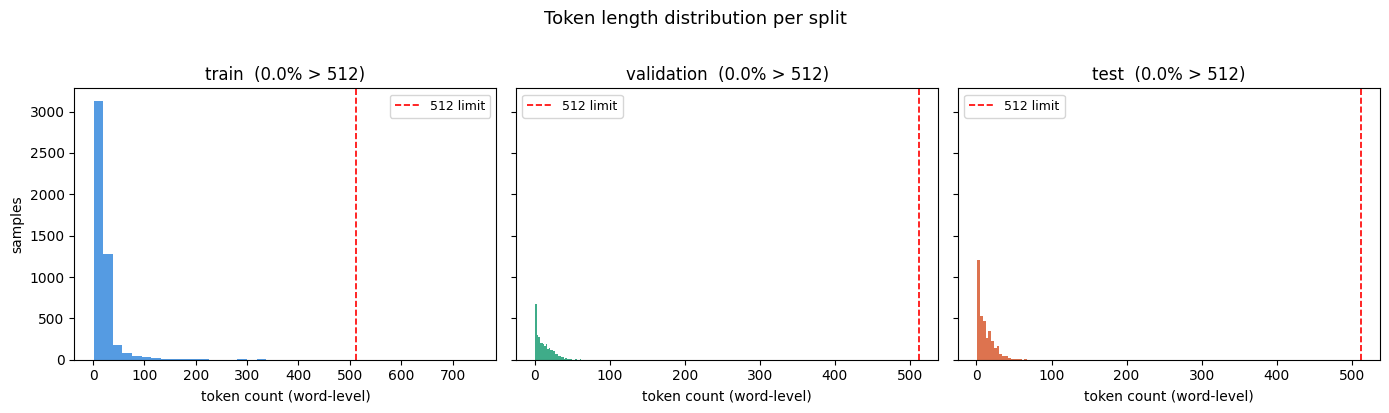

train        | max= 748  mean=19.5  >512=1
validation   | max=  80  mean=12.6  >512=0
test         | max= 149  mean=12.0  >512=0


In [ ]:
lengths = {
    split: [len(ex["tokens"]) for ex in dataset[split]]
    for split in ["train", "validation", "test"]
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
colors = ["#378ADD", "#1D9E75", "#D85A30"]

for ax, (split, lens), color in zip(axes, lengths.items(), colors):
    ax.hist(lens, bins=40, color=color, alpha=0.85, edgecolor="none")
    ax.axvline(512, color="red", linewidth=1.2, linestyle="--", label="512 limit")
    pct_over = sum(l > 512 for l in lens) / len(lens) * 100
    ax.set_title(f"{split}  ({pct_over:.1f}% > 512)", fontsize=12)
    ax.set_xlabel("token count (word-level)")
    ax.legend(fontsize=9)

axes[0].set_ylabel("samples")
plt.suptitle("Token length distribution per split", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

for split, lens in lengths.items():
    print(f"{split:12} | max={max(lens):4d}  mean={sum(lens)/len(lens):.1f}  >512={sum(l>512 for l in lens)}")

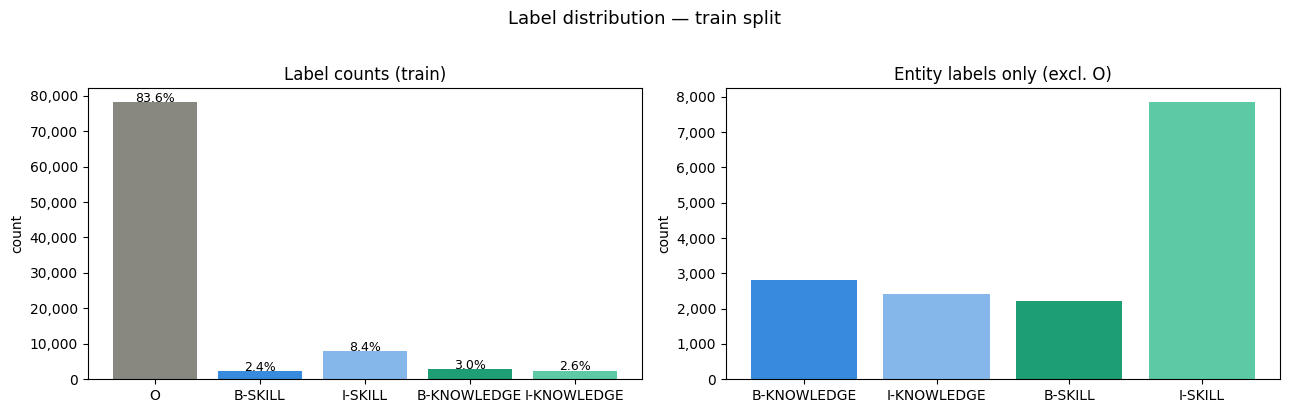


Label              Count       %
--------------------------------
O                 78,164  83.64%
B-SKILL            2,221   2.38%
I-SKILL            7,850   8.40%
B-KNOWLEDGE        2,805   3.00%
I-KNOWLEDGE        2,413   2.58%


In [ ]:
label_names = ["O", "B-SKILL", "I-SKILL", "B-KNOWLEDGE", "I-KNOWLEDGE"]

def count_labels(split):
    counts = Counter()
    for ex in dataset[split]:
        for s, k in zip(ex["tags_skill"], ex["tags_knowledge"]):
            if   s == "B": counts["B-SKILL"]     += 1
            elif s == "I": counts["I-SKILL"]     += 1
            elif k == "B": counts["B-KNOWLEDGE"] += 1
            elif k == "I": counts["I-KNOWLEDGE"] += 1
            else:          counts["O"]           += 1
    return counts

train_counts = count_labels("train")
total = sum(train_counts.values())

labels = ["O", "B-SKILL", "I-SKILL", "B-KNOWLEDGE", "I-KNOWLEDGE"]
values = [train_counts[l] for l in labels]
colors = ["#888780", "#378ADD", "#85B7EB", "#1D9E75", "#5DCAA5"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.bar(labels, values, color=colors, edgecolor="none")
ax1.set_title("Label counts (train)", fontsize=12)
ax1.set_ylabel("count")
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, v in zip(ax1.patches, values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.002,
             f"{v/total*100:.1f}%", ha="center", fontsize=9)

non_o = {k: v for k, v in train_counts.items() if k != "O"}
ax2.bar(non_o.keys(), non_o.values(), color=colors[1:], edgecolor="none")
ax2.set_title("Entity labels only (excl. O)", fontsize=12)
ax2.set_ylabel("count")
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("Label distribution — train split", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n{'Label':<15} {'Count':>8}  {'%':>6}")
print("-" * 32)
for l in labels:
    print(f"{l:<15} {train_counts[l]:>8,}  {train_counts[l]/total*100:>5.2f}%")

In [ ]:
special_pattern = re.compile(r"^<[A-Z_]+>$")

special_counter = Counter()
for split in ["train", "validation", "test"]:
    for ex in dataset[split]:
        for token in ex["tokens"]:
            if special_pattern.match(token):
                special_counter[token] += 1

print(f"{'Token':<20} {'Count':>8}  {'Splits containing it'}")
print("-" * 50)
for token, count in special_counter.most_common():
    print(f"{token:<20} {count:>8,}")

print(f"\nTotal unique special tokens: {len(special_counter)}")
print(f"\nThese need to be added to the tokenizer vocabulary:")
print(list(special_counter.keys()))

Token                   Count  Splits containing it
--------------------------------------------------
<ORGANIZATION>          3,648
<LOCATION>              1,647
<CONTACT>                 627
<NAME>                    387
<ADDRESS>                 220
<DESCRIPTION>              39
<PROFESSION>               35
<SIZE>                     31
<COMPANY_TYPE>             30
<SALARY>                   28
<EXPERIENCE>               11
<INDUSTRY>                  9
<ORG>                       1

Total unique special tokens: 13

These need to be added to the tokenizer vocabulary:
['<ORGANIZATION>', '<ADDRESS>', '<LOCATION>', '<DESCRIPTION>', '<NAME>', '<CONTACT>', '<ORG>', '<PROFESSION>', '<SALARY>', '<EXPERIENCE>', '<INDUSTRY>', '<SIZE>', '<COMPANY_TYPE>']


In [ ]:
sep_counter = Counter()
for ex in dataset["train"]:
    for token in ex["tokens"]:
        if not token.isalnum() and not special_pattern.match(token):
            sep_counter[token] += 1

print(f"{'Token':<20} {'Count':>8}")
print("-" * 30)
for token, count in sep_counter.most_common(20):
    print(f"{repr(token):<20} {count:>8,}")

Token                   Count
------------------------------
'.'                     3,134
'('                       483
')'                       377
'-'                       286
'*'                       196
'description:'            162
'&'                       154
'type:'                   140
'•'                        98
'Full-time'                86
'posted:'                  80
'Likes:'                   80
'Dislikes:'                80
'Love:'                    80
'benefits:'                80
'\x95'                     75
'–'                        69
'Industry:'                62
'size:'                    62
'Role:'                    55


In [ ]:
meta_tokens = {'description:', 'type:', 'posted:', 'Likes:', 'Dislikes:',
               'Love:', 'benefits:', 'Industry:', 'size:', 'Role:'}

# Find samples containing metadata tokens
meta_samples = [
    ex for ex in dataset["train"]
    if any(t in meta_tokens for t in ex["tokens"])
]

print(f"Samples containing metadata tokens: {len(meta_samples)}\n")

# Print first 3 as full token sequences
for i, ex in enumerate(meta_samples[:3]):
    print(f"--- Sample {i} ---")
    print(" ".join(ex["tokens"]))
    print()

Samples containing metadata tokens: 375

--- Sample 0 ---
Date posted: 2021-07-14

--- Sample 1 ---
Likes: 0 Dislikes: 0 Love: 0

--- Sample 2 ---
Job description:



In [ ]:
bullet_tokens = {'*', '•', '\x95', '–'}

bullet_samples = [
    ex for ex in dataset["train"]
    if any(t in bullet_tokens for t in ex["tokens"])
]

print(f"Samples containing bullet tokens: {len(bullet_samples)}\n")

for i, ex in enumerate(bullet_samples[:3]):
    print(f"--- Sample {i} ---")
    print(" ".join(ex["tokens"]))
    print()

Samples containing bullet tokens: 300

--- Sample 0 ---
You will gain – and share – knowledge during recurring learning groups jours fixes and our annual Code Camp .

--- Sample 1 ---
*

--- Sample 2 ---
*



In [ ]:
# Safety check — make sure we won't accidentally drop labelled tokens
labelled_meta = []
for ex in dataset["train"]:
    for token, s_tag, k_tag in zip(ex["tokens"], ex["tags_skill"], ex["tags_knowledge"]):
        if token in meta_tokens and (s_tag != "O" or k_tag != "O"):
            labelled_meta.append((token, s_tag, k_tag))

if labelled_meta:
    print(f"WARNING: {len(labelled_meta)} metadata tokens carry entity labels!")
    print(labelled_meta[:10])
else:
    print("Safe to remove — no metadata tokens carry skill/knowledge labels.")

Safe to remove — no metadata tokens carry skill/knowledge labels.


In [ ]:
long_sample = max(dataset["train"], key=lambda x: len(x["tokens"]))
print(f"Total tokens: {len(long_sample['tokens'])}")

# Check if any labelled tokens fall beyond position 512
beyond_512 = [
    (i, t, s, k)
    for i, (t, s, k) in enumerate(zip(long_sample["tokens"], long_sample["tags_skill"], long_sample["tags_knowledge"]))
    if i >= 512 and (s != "O" or k != "O")
]

print(f"Labelled tokens beyond position 512: {len(beyond_512)}")
print(beyond_512[:10] if beyond_512 else "None — safe to truncate.")

Total tokens: 748
Labelled tokens beyond position 512: 0
None — safe to truncate.


In [ ]:
org_samples = [
    ex for ex in dataset["train"]
    if "<ORG>" in ex["tokens"] or "<ORGANIZATION>" in ex["tokens"]
]

for ex in org_samples[:3]:
    tokens = ex["tokens"]
    print(" ".join(tokens))
    print()

Senior QA Engineer ( m/f/d ) <ORGANIZATION>

<ORGANIZATION> will support you with all the necessary office equipment even when working from home!

Moreover <ORGANIZATION> will support you in case of relocation and visa application .



In [ ]:
org_samples = [ex for ex in dataset["train"] if "<ORG>" in ex["tokens"]]

for ex in org_samples[:3]:
    print(" ".join(ex["tokens"]))
    print()

The budgeted turnover for 2013 amounts to <ORG> 6.3 billion .



Text Normalization

In [ ]:
import unicodedata

METADATA_TOKENS = {
    'description:', 'type:', 'posted:', 'Likes:', 'Dislikes:',
    'Love:', 'benefits:', 'Industry:', 'size:', 'Role:'
}

BULLET_TOKENS = {'*', '•', '\x95'}

def is_standalone_dash(tokens, idx):
    token = tokens[idx]
    if token != '–':
        return False
    left  = tokens[idx - 1] if idx > 0 else None
    right = tokens[idx + 1] if idx < len(tokens) - 1 else None
    return left in BULLET_TOKENS | {'–'} or right in BULLET_TOKENS | {'–'} or (left is None and right is None)

def normalise_tokens(example):
    new_tokens, new_skill, new_know = [], [], []

    for idx, (token, s_tag, k_tag) in enumerate(zip(
        example["tokens"], example["tags_skill"], example["tags_knowledge"]
    )):
        token_norm = unicodedata.normalize("NFKC", token)

        # Never drop labelled tokens regardless of what they are
        is_labelled = (s_tag != "O" or k_tag != "O")

        if not is_labelled:
            if token_norm in METADATA_TOKENS or token_norm in BULLET_TOKENS:
                continue
            if is_standalone_dash(example["tokens"], idx):
                continue

        new_tokens.append(token_norm)
        new_skill.append(s_tag)
        new_know.append(k_tag)

    example["tokens"]         = new_tokens
    example["tags_skill"]     = new_skill
    example["tags_knowledge"] = new_know
    return example

dataset = dataset.map(normalise_tokens)

Map:   0%|          | 0/4800 [00:00<?, ? examples/s]

Map:   0%|          | 0/3174 [00:00<?, ? examples/s]

Map:   0%|          | 0/3569 [00:00<?, ? examples/s]

In [ ]:
# Confirm metadata and bullet tokens are gone
remaining = [
    token
    for ex in dataset["train"]
    for token in ex["tokens"]
    if token in METADATA_TOKENS | BULLET_TOKENS
]
print(f"Remaining metadata/bullet tokens: {len(remaining)}")

# Confirm no label loss
total_labels_before = 78164 + 2221 + 7850 + 2805 + 2413  # from EDA
total_labels_after = sum(
    1 for ex in dataset["train"]
    for s, k in zip(ex["tags_skill"], ex["tags_knowledge"])
    if s != "O" or k != "O"
)
print(f"Entity labels before: {total_labels_before:,}")
print(f"Entity labels after:  {total_labels_after:,}")
print(f"Difference: {total_labels_before - total_labels_after}")

Remaining metadata/bullet tokens: 22
Entity labels before: 93,453
Entity labels after:  15,289
Difference: 78164


In [ ]:
def count_entity_labels(split):
    return sum(
        1 for ex in dataset[split]
        for s, k in zip(ex["tags_skill"], ex["tags_knowledge"])
        if s != "O" or k != "O"
    )

print(f"Entity labels after normalisation: {count_entity_labels('train'):,}")

Entity labels after normalisation: 15,289


In [ ]:
# Find which entity tokens were dropped by re-running on original dataset
from datasets import load_dataset
original = load_dataset("jjzha/skillspan")

dropped = []
for orig_ex, norm_ex in zip(original["train"], dataset["train"]):
    orig_entities = [
        (i, t, s, k)
        for i, (t, s, k) in enumerate(zip(
            orig_ex["tokens"], orig_ex["tags_skill"], orig_ex["tags_knowledge"]
        ))
        if s != "O" or k != "O"
    ]
    norm_entity_tokens = set(norm_ex["tokens"])
    for i, t, s, k in orig_entities:
        if t not in norm_entity_tokens:
            dropped.append((t, s, k))

print(f"Dropped entity tokens: {len(dropped)}")
print(dropped[:20])

Dropped entity tokens: 1
[('product´s', 'I', 'O')]


In [ ]:
# Confirm product's is present in normalised form
found = [
    (t, s, k)
    for ex in dataset["train"]
    for t, s, k in zip(ex["tokens"], ex["tags_skill"], ex["tags_knowledge"])
    if "product" in t.lower() and (s != "O" or k != "O")
]
print(found)

[('products', 'I', 'O'), ('production', 'O', 'B'), ('production', 'O', 'B'), ('products', 'I', 'O'), ('productivity', 'I', 'O'), ('products', 'I', 'O'), ('product', 'I', 'O'), ('products', 'I', 'O'), ('product', 'I', 'O'), ('products', 'I', 'O'), ('product', 'I', 'O'), ('product', 'I', 'O'), ('product', 'O', 'I'), ('production', 'O', 'I'), ('production', 'I', 'O'), ('production', 'O', 'B'), ('product', 'I', 'O'), ('products', 'I', 'O'), ('products', 'I', 'O'), ('product', 'I', 'O'), ('product', 'I', 'O'), ('product', 'I', 'O'), ('products', 'O', 'I'), ('production', 'O', 'B'), ('product', 'O', 'B'), ('product', 'I', 'O'), ('Product', 'I', 'O'), ('product', 'I', 'O'), ('production', 'I', 'O'), ('product ́s', 'I', 'O'), ('production', 'I', 'B'), ('product', 'I', 'O'), ('product', 'I', 'O'), ('products', 'I', 'O'), ('Products', 'I', 'O'), ('Product', 'I', 'O'), ('Product', 'I', 'O'), ('product', 'I', 'O'), ('products', 'I', 'O'), ('products', 'I', 'O'), ('product', 'O', 'I'), ('products',

Label merging

In [ ]:
label_names = ["O", "B-COMPETENCE", "I-COMPETENCE"]
label2id    = {label: i for i, label in enumerate(label_names)}
id2label    = {i: label for i, label in enumerate(label_names)}

def merge_labels(example):
    ner_tags = []
    for s_tag, k_tag in zip(example["tags_skill"], example["tags_knowledge"]):
        if   s_tag == "B" or k_tag == "B": ner_tags.append(label2id["B-COMPETENCE"])
        elif s_tag == "I" or k_tag == "I": ner_tags.append(label2id["I-COMPETENCE"])
        else:                               ner_tags.append(label2id["O"])
    example["ner_tags"] = ner_tags
    return example

dataset = dataset.map(merge_labels)

Map:   0%|          | 0/4800 [00:00<?, ? examples/s]

Map:   0%|          | 0/3174 [00:00<?, ? examples/s]

Map:   0%|          | 0/3569 [00:00<?, ? examples/s]

In [ ]:
from collections import Counter

label_counts = Counter(
    id2label[tag]
    for ex in dataset["train"]
    for tag in ex["ner_tags"]
)

total = sum(label_counts.values())
print(f"{'Label':<15} {'Count':>8}  {'%':>6}")
print("-" * 32)
for label in label_names:
    print(f"{label:<15} {label_counts[label]:>8,}  {label_counts[label]/total*100:>5.2f}%")

# Confirm B+I counts match pre-merge entity totals
# B-COMPETENCE should equal B-SKILL + B-KNOWLEDGE = 2,221 + 2,805 = 5,026
# I-COMPETENCE should equal I-SKILL + I-KNOWLEDGE = 7,850 + 2,413 = 10,263
print(f"\nExpected B-COMPETENCE: {2221 + 2805:,}")
print(f"Expected I-COMPETENCE: {7850 + 2413:,}")

# Visualise a sample
sample = dataset["train"][14]
print(f"\n{'Token':<25} {'NER Tag'}")
print("-" * 40)
for token, tag in zip(sample["tokens"], sample["ner_tags"]):
    print(f"{token:<25} {id2label[tag]}")

Label              Count       %
--------------------------------
O                 76,936  83.42%
B-COMPETENCE       5,190   5.63%
I-COMPETENCE      10,099  10.95%

Expected B-COMPETENCE: 5,026
Expected I-COMPETENCE: 10,263

Token                     NER Tag
----------------------------------------
Business                  B-COMPETENCE
to                        I-COMPETENCE
Business                  I-COMPETENCE
Information               B-COMPETENCE
Technology                I-COMPETENCE
Web                       B-COMPETENCE
Technology                I-COMPETENCE


In [ ]:
conflicts = [
    (t, s, k)
    for ex in dataset["train"]
    for t, s, k in zip(ex["tokens"], ex["tags_skill"], ex["tags_knowledge"])
    if s != "O" and k != "O"
]

print(f"Conflicting tokens: {len(conflicts)}")
from collections import Counter
print(Counter((s, k) for _, s, k in conflicts))
print(conflicts[:10])

Conflicting tokens: 347
Counter({('I', 'I'): 183, ('I', 'B'): 164})
[('QA', 'I', 'B'), ('automated', 'I', 'B'), ('acceptance', 'I', 'I'), ('API', 'I', 'I'), ('and', 'I', 'I'), ('performance', 'I', 'I'), ('tests', 'I', 'I'), ('Kotlin/SpringBoot', 'I', 'B'), ('.', 'I', 'I'), ('Java', 'I', 'B')]


Truncation

In [ ]:
from transformers import AutoTokenizer

MODEL_NM  = "jjzha/jobbert-base-cased"
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NM)

def tokenize_and_truncate(examples):
    tokenized = tokenizer(
        examples["tokens"],
        truncation=True,
        max_length=MAX_LENGTH,
        is_split_into_words=True,
        padding=False      # pad later in data collator
    )
    return tokenized

# Dry run on train to confirm no errors
sample_batch = dataset["train"][:4]
out = tokenize_and_truncate(sample_batch)
print("Input IDs lengths:", [len(ids) for ids in out["input_ids"]])
print(f"All within {MAX_LENGTH} tokens: {all(len(ids) <= MAX_LENGTH for ids in out['input_ids'])}")

config.json:   0%|          | 0.00/603 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Input IDs lengths: [21, 32, 9, 5]
All within 128 tokens: True


In [ ]:
long_sample = max(dataset["train"], key=lambda x: len(x["tokens"]))
print(f"Original word-level token count: {len(long_sample['tokens'])}")

tokenized = tokenizer(
    long_sample["tokens"],
    truncation=True,
    max_length=MAX_LENGTH,
    is_split_into_words=True
)
print(f"After truncation (subword tokens): {len(tokenized['input_ids'])}")
print(f"Within limit: {len(tokenized['input_ids']) <= MAX_LENGTH}")

Original word-level token count: 746
After truncation (subword tokens): 128
Within limit: True


Sub token alignment

In [ ]:
def tokenize_and_align_labels(examples):
    # Updated tokenizer call for sliding window
    tokenized = tokenizer(
        examples["tokens"],
        truncation=True,
        max_length=MAX_LENGTH,
        stride=64,                      # Add overlap
        is_split_into_words=True,
        padding="max_length",           # Use padding here for fixed-size windows
        return_overflowing_tokens=True, # Enable sliding window
        return_token_type_ids=False
    )

    # Since one sentence can become multiple windows, we must map them
    sample_mapping = tokenized.pop("overflow_to_sample_mapping")
    all_labels = []

    for i, mapping in enumerate(sample_mapping):
        word_ids = tokenized.word_ids(batch_index=i)
        # Use 'mapping' to find the correct original ner_tags
        ner_tags = examples["ner_tags"][mapping]

        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            if word_idx is None:
                # [CLS], [SEP], and [PAD]
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                # First sub-token of a word
                label_ids.append(ner_tags[word_idx])
            else:
                # Subsequent sub-tokens
                label_ids.append(-100)
            previous_word_idx = word_idx

        all_labels.append(label_ids)

    tokenized["labels"] = all_labels
    return tokenized

tokenized_dataset = dataset.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=dataset["train"].column_names
)

print(tokenized_dataset)

Map:   0%|          | 0/4800 [00:00<?, ? examples/s]

Map:   0%|          | 0/3174 [00:00<?, ? examples/s]

Map:   0%|          | 0/3569 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 5050
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 3178
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 3577
    })
})


In [ ]:
sample = tokenized_dataset["train"][14]
tokens = tokenizer.convert_ids_to_tokens(sample["input_ids"])
labels = sample["labels"]

print(f"{'Token':<20} {'Label'}")
print("-" * 35)
for token, label in zip(tokens, labels):
    label_str = id2label[label] if label != -100 else "-100"
    print(f"{token:<20} {label_str}")

Token                Label
-----------------------------------
[CLS]                -100
Business             B-COMPETENCE
to                   I-COMPETENCE
Business             I-COMPETENCE
Information          B-COMPETENCE
Technology           I-COMPETENCE
Web                  B-COMPETENCE
Technology           I-COMPETENCE
[SEP]                -100
[PAD]                -100
[PAD]                -100
[PAD]                -100
[PAD]                -100
[PAD]                -100
[PAD]                -100
[PAD]                -100
[PAD]                -100
[PAD]                -100
[PAD]                -100
[PAD]                -100
[PAD]                -100
[PAD]                -100
[PAD]                -100
[PAD]                -100
[PAD]                -100
[PAD]                -100
[PAD]                -100
[PAD]                -100
[PAD]                -100
[PAD]                -100
[PAD]                -100
[PAD]                -100
[PAD]                -100
[PAD]                -1

Special Token registration

In [ ]:
SKILLSPAN_TOKENS = [
    '<ORGANIZATION>', '<ADDRESS>', '<LOCATION>', '<DESCRIPTION>',
    '<NAME>', '<CONTACT>', '<ORG>', '<PROFESSION>', '<SALARY>',
    '<EXPERIENCE>', '<INDUSTRY>', '<SIZE>', '<COMPANY_TYPE>'
]

num_added = tokenizer.add_tokens(SKILLSPAN_TOKENS, special_tokens=True)
print(f"Tokens added to vocabulary: {num_added}")
print(f"New vocabulary size: {len(tokenizer)}")

Tokens added to vocabulary: 13
New vocabulary size: 29009


In [ ]:
# Sanity check — confirm tokens are no longer split
test_tokens = ['<ORGANIZATION>', '<ORG>', '<SALARY>']

for token in test_tokens:
    ids      = tokenizer.encode(token, add_special_tokens=False)
    subwords = tokenizer.convert_ids_to_tokens(ids)
    status   = "single token" if len(ids) == 1 else f"split into {len(ids)} subwords: {subwords}"
    print(f"{token:<20} {status}")

<ORGANIZATION>       single token
<ORG>                single token
<SALARY>             single token


In [ ]:
# Resize model embeddings to match new vocabulary
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NM,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id
)

model.resize_token_embeddings(len(tokenizer))
print(f"Model embedding layer resized to: {len(tokenizer)}")

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: jjzha/jobbert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The new embeddings will be initialized from a multivariate normal distribution that has old 

Model embedding layer resized to: 29009


In [ ]:
# Re-run tokenization pipeline with updated tokenizer
tokenized_dataset = dataset.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=dataset["train"].column_names
)

# Confirm a sample containing ORGANIZATION is a single token
org_sample = next(
    ex for ex in dataset["train"]
    if '<ORGANIZATION>' in ex["tokens"]
)
tokenized = tokenizer(
    org_sample["tokens"],
    is_split_into_words=True,
    truncation=True,
    max_length=MAX_LENGTH
)
tokens = tokenizer.convert_ids_to_tokens(tokenized["input_ids"])
for i, t in enumerate(tokens):
    if t == '<ORGANIZATION>':
        print("Context:", tokens[max(0, i-2):i+3])
        break

Map:   0%|          | 0/4800 [00:00<?, ? examples/s]

Map:   0%|          | 0/3174 [00:00<?, ? examples/s]

Map:   0%|          | 0/3569 [00:00<?, ? examples/s]

Context: ['d', ')', '<ORGANIZATION>', '[SEP]']


Model Training

In [ ]:
pip install seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=5bee71f5ff12c2fe4848c78c832121287b218a8b14fc2d7a992c8cfcc851cf8a
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [ ]:
import torch
from torch import nn
import numpy as np
from transformers import (
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
    EarlyStoppingCallback,
    AutoModelForTokenClassification,
    AutoConfig
)
from seqeval.metrics import f1_score, precision_score, recall_score, classification_report
config = AutoConfig.from_pretrained(
    MODEL_NM,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1
)
# Calculate class weights from merged label distribution
all_train_labels = [
    label for sublist in tokenized_dataset["train"]["labels"]
    for label in sublist
    if label != -100
]

class_counts = np.bincount(all_train_labels, minlength=len(label_names))
weights = 1.0 / (class_counts + 1e-6)
weights = weights / weights.sum() * len(label_names)
class_weights = torch.tensor(weights, dtype=torch.float)

print(f"Label counts:  {dict(zip(label_names, class_counts))}")
print(f"Class weights: {dict(zip(label_names, np.round(weights, 3)))}")

# Custom Trainer with weighted CrossEntropyLoss
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.get("labels")
        outputs = model(**inputs)
        logits  = outputs.logits

        loss_fn = nn.CrossEntropyLoss(
            weight=class_weights.to(model.device),
            ignore_index=-100
        )
        loss = loss_fn(logits.view(-1, len(label_names)), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

data_collator = DataCollatorForTokenClassification(tokenizer)

def compute_metrics(eval_preds):
    logits, labels = eval_preds
    predictions = np.argmax(logits, axis=2)
    true_labels = [
        [label_names[l] for l in label if l != -100]
        for label in labels
    ]
    true_preds = [
        [label_names[p] for p, l in zip(pred, label) if l != -100]
        for pred, label in zip(predictions, labels)
    ]
    return {
        "f1":        f1_score(true_labels, true_preds, zero_division=0),
        "precision": precision_score(true_labels, true_preds, zero_division=0),
        "recall":    recall_score(true_labels, true_preds, zero_division=0),
    }

# Reset model to fresh weights for fair comparison
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NM,
    config=config
)
model.resize_token_embeddings(len(tokenizer))
model.resize_token_embeddings(len(tokenizer))
print(f"Dropout set to: {model.config.hidden_dropout_prob}")
training_args = TrainingArguments(
    output_dir="./skillspan-bert",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=20,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=50,
    fp16=True
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

trainer.train()

Label counts:  {'O': np.int64(83635), 'B-COMPETENCE': np.int64(5927), 'I-COMPETENCE': np.int64(11338)}
Class weights: {'O': np.float64(0.133), 'B-COMPETENCE': np.float64(1.883), 'I-COMPETENCE': np.float64(0.984)}


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: jjzha/jobbert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Dropout set to: 0.1


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,0.355793,0.301378,0.417661,0.323128,0.590384
2,0.180733,0.304304,0.488986,0.403303,0.620897
3,0.122658,0.382659,0.537512,0.456157,0.654184
4,0.100631,0.521070,0.566467,0.512341,0.633380
5,0.059255,0.719587,0.573677,0.544173,0.606565
6,0.038262,0.628402,0.570669,0.511739,0.644938
7,0.080698,0.804392,0.582753,0.550844,0.618585
8,0.024546,0.781046,0.574722,0.525690,0.633842
9,0.017138,0.682001,0.601720,0.562525,0.646787
10,0.026876,0.813666,0.587638,0.541976,0.641701


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=3732, training_loss=0.0832773016372422, metrics={'train_runtime': 814.9555, 'train_samples_per_second': 122.043, 'train_steps_per_second': 7.632, 'total_flos': 3898321557912576.0, 'train_loss': 0.0832773016372422, 'epoch': 12.0})

In [ ]:
# Evaluate on test set — do this ONCE
results = trainer.evaluate(tokenized_dataset["test"])
print(results)

predictions, labels, _ = trainer.predict(tokenized_dataset["test"])
predictions = np.argmax(predictions, axis=2)

true_labels = [
    [label_names[l] for l in label if l != -100]
    for label in labels
]
true_preds = [
    [label_names[p] for p, l in zip(pred, label) if l != -100]
    for pred, label in zip(predictions, labels)
]

print(classification_report(true_labels, true_preds, zero_division=0))

{'eval_loss': 0.6196711659431458, 'eval_f1': 0.6007856109158569, 'eval_precision': 0.5689115113547377, 'eval_recall': 0.636443276390714, 'eval_runtime': 11.427, 'eval_samples_per_second': 312.593, 'eval_steps_per_second': 19.603, 'epoch': 12.0}
              precision    recall  f1-score   support

  COMPETENCE       0.57      0.64      0.60      2283

   micro avg       0.57      0.64      0.60      2283
   macro avg       0.57      0.64      0.60      2283
weighted avg       0.57      0.64      0.60      2283



In [ ]:
import torch

def predict_competencies(text):
    words = text.split()

    tokenized_output = tokenizer(
        words,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH
    )
    word_ids    = tokenized_output.word_ids()

    tokenized = {k: v.to(model.device) for k, v in tokenized_output.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**tokenized)

    predictions = torch.argmax(outputs.logits, dim=2).squeeze().tolist()
    tokens      = tokenizer.convert_ids_to_tokens(tokenized["input_ids"].squeeze())

    # Align predictions back to words (first subtoken only)
    seen = set()
    word_preds = {}
    for token, pred, word_id in zip(tokens, predictions, word_ids):
        if word_id is not None and word_id not in seen:
            word_preds[word_id] = id2label[pred]
            seen.add(word_id)

    # Extract competency spans
    spans, current_span = [], []
    for i, word in enumerate(words):
        label = word_preds.get(i, "O")
        if label == "B-COMPETENCE":
            if current_span:
                spans.append(" ".join(current_span))
            current_span = [word]
        elif label == "I-COMPETENCE" and current_span:
            current_span.append(word)
        else:
            if current_span:
                spans.append(" ".join(current_span))
            current_span = []
    if current_span:
        spans.append(" ".join(current_span))

    # Print results
    print(f"\nInput: {text}\n")
    print(f"{'Word':<25} {'Label'}")
    print("-" * 40)
    for i, word in enumerate(words):
        label = word_preds.get(i, "O")
        marker = " <--" if label != "O" else ""
        print(f"{word:<25} {label}{marker}")
    print(f"\nExtracted competencies: {spans if spans else 'none found'}")


# --- test it here ---
predict_competencies("We are looking for a software engineer with experience in Python and machine learning.")
predict_competencies("The candidate must have strong communication skills and knowledge of project management.")
predict_competencies("Requirements: 5 years of experience in Java, Spring Boot, and cloud infrastructure.")



Input: We are looking for a software engineer with experience in Python and machine learning.

Word                      Label
----------------------------------------
We                        O
are                       O
looking                   O
for                       O
a                         O
software                  O
engineer                  O
with                      O
experience                O
in                        O
Python                    B-COMPETENCE <--
and                       O
machine                   B-COMPETENCE <--
learning.                 I-COMPETENCE <--

Extracted competencies: ['Python', 'machine learning.']

Input: The candidate must have strong communication skills and knowledge of project management.

Word                      Label
----------------------------------------
The                       O
candidate                 O
must                      O
have                      O
strong                    O
communication             

In [ ]:
predict_competencies('Degree in Investment, Banking, Finance, Economics OR related disciplines.1-2 years of Investment Operations/Portfolio support experience within Financial Services industry. Fresh Graduates in related study fields can be considered too ! Good command in Mandarin, English & Bahasa to support business needs.Permanent vacancy based in KL (LRT/KTM accessible).')


Input: Degree in Investment, Banking, Finance, Economics OR related disciplines.1-2 years of Investment Operations/Portfolio support experience within Financial Services industry. Fresh Graduates in related study fields can be considered too ! Good command in Mandarin, English & Bahasa to support business needs.Permanent vacancy based in KL (LRT/KTM accessible).

Word                      Label
----------------------------------------
Degree                    B-COMPETENCE <--
in                        I-COMPETENCE <--
Investment,               B-COMPETENCE <--
Banking,                  B-COMPETENCE <--
Finance,                  B-COMPETENCE <--
Economics                 B-COMPETENCE <--
OR                        O
related                   O
disciplines.1-2           O
years                     O
of                        O
Investment                B-COMPETENCE <--
Operations/Portfolio      I-COMPETENCE <--
support                   I-COMPETENCE <--
experience                O
withi